In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import polars as pl
import os
import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print(os.getcwd())

c:\Users\eliot.nehme\repositories\memoire-ia\codes


In [3]:
# avant de décider du type de chaque colonne. 
# C'est un peu plus lent (quelques secondes), mais c'est 100% sûr.

table_sinistres = pl.read_csv(
    "../data/car_insurance_fraud_dataset.csv", 
    infer_schema_length=None  # <--- Le secret est là !
)

print(f"Dimensions : {table_sinistres.shape}") # Affiche le nombre de lignes/colonnes
print(table_sinistres.head())

Dimensions : (30000, 24)
shape: (5, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ policy_id ┆ policy_st ┆ policy_de ┆ policy_an ┆ … ┆ police_re ┆ claim_amo ┆ total_cla ┆ fraud_re │
│ ---       ┆ ate       ┆ ductible  ┆ nual_prem ┆   ┆ port_avai ┆ unt       ┆ im_amount ┆ ported   │
│ str       ┆ ---       ┆ ---       ┆ ium       ┆   ┆ lable     ┆ ---       ┆ ---       ┆ ---      │
│           ┆ str       ┆ i64       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ str      │
│           ┆           ┆           ┆ f64       ┆   ┆ str       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ POL100000 ┆ GA        ┆ 400       ┆ 1430.78   ┆ … ┆ Yes       ┆ 8161.36   ┆ 11677.6   ┆ Y        │
│ POL100001 ┆ PA        ┆ 300       ┆ 854.49    ┆ … ┆ No        ┆ 18561.79  ┆ 18027.81  ┆ N        │
│ POL100002 ┆ MI        ┆ 400       ┆ 1247.28   ┆ …

In [4]:
print(table_sinistres['fraud_reported'].value_counts())

shape: (2, 2)
┌────────────────┬───────┐
│ fraud_reported ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ Y              ┆ 3440  │
│ N              ┆ 26560 │
└────────────────┴───────┘


In [9]:
# Filter for fraudulent claims and get insured_sex value counts with percentages
fraudulent = table_sinistres.filter(pl.col('fraud_reported') == 'Y')
sex_counts = fraudulent['insured_sex'].value_counts()
sex_counts = sex_counts.with_columns((pl.col('count') / pl.sum('count') * 100).alias('percentage'))
print(sex_counts)

shape: (3, 3)
┌─────────────┬───────┬────────────┐
│ insured_sex ┆ count ┆ percentage │
│ ---         ┆ ---   ┆ ---        │
│ str         ┆ u32   ┆ f64        │
╞═════════════╪═══════╪════════════╡
│ OTHER       ┆ 1138  ┆ 33.081395  │
│ FEMALE      ┆ 1118  ┆ 32.5       │
│ MALE        ┆ 1184  ┆ 34.418605  │
└─────────────┴───────┴────────────┘


In [14]:
# 1. Charger les données
df = pd.read_csv("../data/car_insurance_fraud_dataset.csv")

# 2. Nettoyage de base
# La colonne 'authorities_contacted' avait des valeurs manquantes, on les remplace par 'None'
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')

# On supprime 'policy_id' et 'incident_date' car l'ID n'a pas de pouvoir prédictif 
# (Pour aller plus loin, on pourrait extraire le mois/jour de la date, mais on simplifie pour l'instant)
df = df.drop(columns=['policy_id', 'incident_date'])

# 3. Transformer la variable cible en 0 et 1 (N=0, Y=1)
df['fraud_reported'] = df['fraud_reported'].map({'N': 0, 'Y': 1})

# 4. Encodage des variables catégorielles (texte -> chiffres)
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Séparer les variables explicatives (X) et la cible (y)
X = df_encoded.drop('fraud_reported', axis=1)
y = df_encoded['fraud_reported']

# 6. Séparer en Train (80%) et Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Normaliser les données numériques (mettre toutes les valeurs à la même échelle)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- NOUVELLE ÉTAPE 7 bis : SMOTE ---
# On rééquilibre les classes en créant des données synthétiques de fraude
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# --- ÉTAPE 8 MODIFIÉE ---
# Entraînement du modèle (Random Forest) sur les données RÉÉQUILIBRÉES
# (On peut enlever le class_weight='balanced' car SMOTE a déjà fait le travail)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled) # <-- Attention à bien utiliser les variables _resampled ici !

# 9. Prédictions sur le jeu de test
y_pred = rf_model.predict(X_test_scaled)

# 10. Évaluation des résultats
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

C:\Users\eliot.nehme\AppData\Local\Temp\ipykernel_14476\3158139207.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Matrice de confusion :
[[5312    0]
 [ 688    0]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.00      0.00      0.00       688

    accuracy                           0.89      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.78      0.89      0.83      6000



c:\Users\eliot.nehme\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eliot.nehme\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eliot.nehme\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [16]:
#ON ESSAYE DE VOIR SI LE RENDU DES FRAUDES EST CONVAINCANT
#on utilise le fichier réduit avec des scores de suspicion >= 30

suspects_avec_colonne_fraude = pl.read_csv(
    "../data/suspects_avec_colonne_fraude_v3.csv", 
    separator=';',  # <--- La petite modification est ici !
    infer_schema_length=None
)

# print(suspects_avec_colonne_fraude.head())

vue_reduite = suspects_avec_colonne_fraude.select([
    "policy_id",
    "suspicion_score",
    "fraud_reported"
])

print(vue_reduite.head())

# 1. On stocke le tableau de comptage dans une variable
comptage_fraude = vue_reduite['fraud_reported'].value_counts()

# 2. On ajoute la colonne pourcentage (arrondie à 2 décimales pour faire propre)
comptage_final = comptage_fraude.with_columns(
    (pl.col("count") / pl.col("count").sum() * 100).round(2).alias("pourcentage")
)

# 3. On affiche le résultat final
print(comptage_final)

shape: (5, 3)
┌───────────┬─────────────────┬────────────────┐
│ policy_id ┆ suspicion_score ┆ fraud_reported │
│ ---       ┆ ---             ┆ ---            │
│ str       ┆ f64             ┆ str            │
╞═══════════╪═════════════════╪════════════════╡
│ POL102803 ┆ 115.0           ┆ Y              │
│ POL125690 ┆ 113.0           ┆ N              │
│ POL122238 ┆ 110.0           ┆ N              │
│ POL100113 ┆ 105.0           ┆ Y              │
│ POL105503 ┆ 103.0           ┆ N              │
└───────────┴─────────────────┴────────────────┘
shape: (2, 3)
┌────────────────┬───────┬─────────────┐
│ fraud_reported ┆ count ┆ pourcentage │
│ ---            ┆ ---   ┆ ---         │
│ str            ┆ u32   ┆ f64         │
╞════════════════╪═══════╪═════════════╡
│ Y              ┆ 889   ┆ 25.55       │
│ N              ┆ 2591  ┆ 74.45       │
└────────────────┴───────┴─────────────┘


C:\Users\eliot.nehme\AppData\Local\Temp\ipykernel_28552\3851876651.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=score_suspicion_pd, x='fraud_reported', y='suspicion_score', palette=['#4CB391', '#E74C3C'])


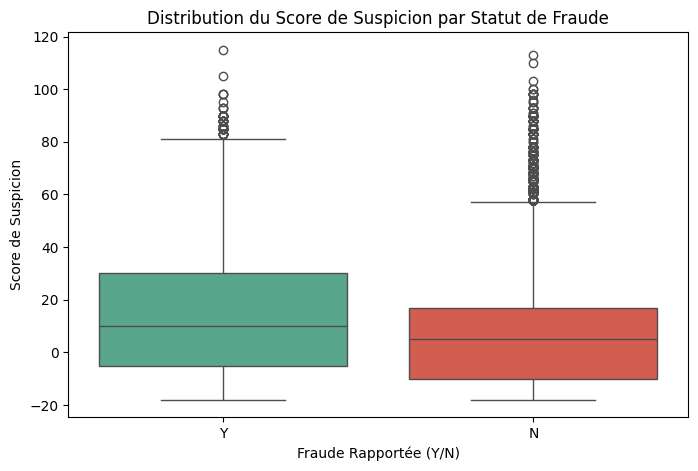

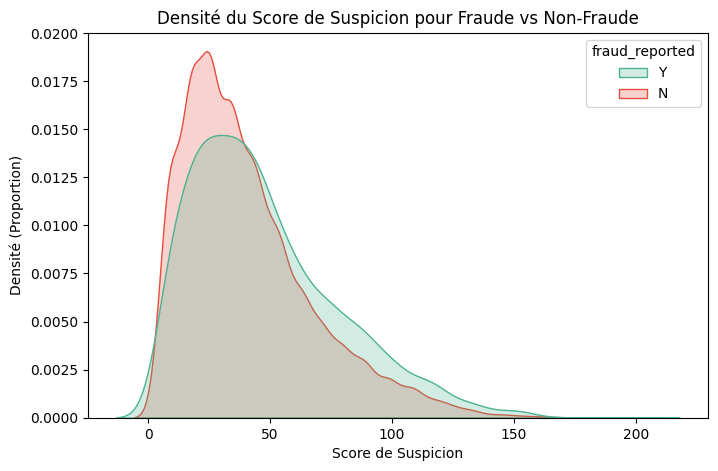

In [18]:
#on va visualiser s'il y a une corrélation entre le score de suspicion et la fraude déclarée

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement des données
score_suspicion = pl.read_csv("../data/tout_score_suspicion.csv", separator=";")

# 2. Conversion en Pandas 
# (Seaborn est une librairie graphique qui fonctionne de manière optimale avec Pandas)
score_suspicion_pd = score_suspicion.to_pandas()

# --- GRAPHIQUE 1 : La Boîte à Moustaches ---
plt.figure(figsize=(8, 5))
# J'utilise une palette de couleurs classique : Vert pour N, Rouge pour Y
sns.boxplot(data=score_suspicion_pd, x='fraud_reported', y='suspicion_score', palette=['#4CB391', '#E74C3C'])
plt.title('Distribution du Score de Suspicion par Statut de Fraude')
plt.xlabel('Fraude Rapportée (Y/N)')
plt.ylabel('Score de Suspicion')

# On sauvegarde l'image pour ton mémoire
plt.savefig("boxplot_fraude.png", dpi=300, bbox_inches='tight')
plt.show()

# --- GRAPHIQUE 2 : Le Graphique de Densité ---
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_pd, x='suspicion_score', hue='fraud_reported', fill=True, common_norm=False, palette=['#4CB391', '#E74C3C'])
plt.title('Densité du Score de Suspicion pour Fraude vs Non-Fraude')
plt.xlabel('Score de Suspicion')
plt.ylabel('Densité (Proportion)')

# On sauvegarde l'image
plt.savefig("densite_fraude.png", dpi=300, bbox_inches='tight')
plt.show()


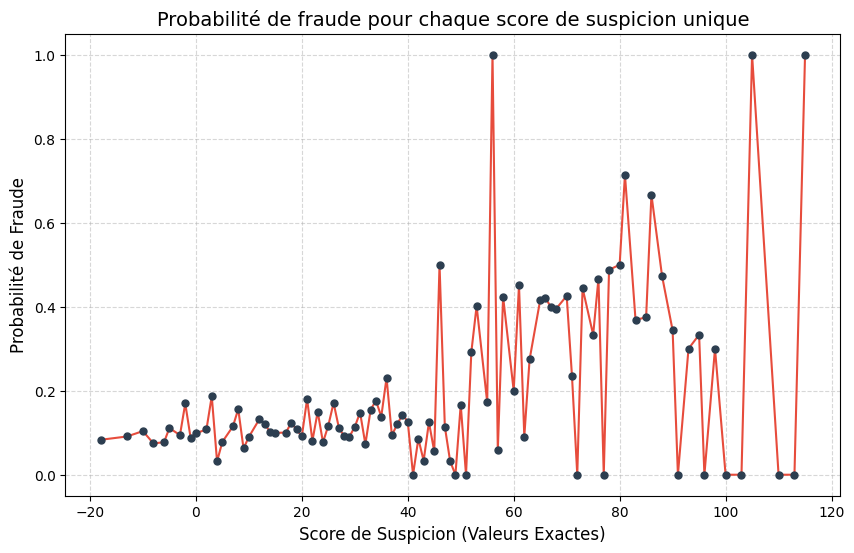

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Conversion en Pandas (Assure-toi que df est ton dataframe de départ)
score_suspicion_pd = score_suspicion.to_pandas() 

# 1 bis. Création d'une version numérique de la variable cible pour calculer la probabilité
score_suspicion_pd['fraud_binary'] = score_suspicion_pd['fraud_reported'].map({'N': 0, 'Y': 1})

# 2. On calcule la probabilité pour CHAQUE score exact (sans faire de tranches)
# On groupe par le score lui-même, on calcule la moyenne (qui est la proba) et on compte
proba_par_score = score_suspicion_pd.groupby('suspicion_score')['fraud_binary'].agg(['mean', 'count']).reset_index()

# Facultatif : On peut filtrer pour ne garder que les scores qui ont un minimum de données (par ex: au moins 3 dossiers)
# pour éviter qu'un seul dossier frauduleux isolé fasse un pic à 100% de probabilité.
# Si tu veux TOUT voir, commente cette ligne avec un #
proba_par_score = proba_par_score[proba_par_score['count'] > 1] 

# 3. Création du graphique
plt.figure(figsize=(10, 6))

plt.plot(
    proba_par_score['suspicion_score'], 
    proba_par_score['mean'], 
    marker='o',               
    linestyle='-',            
    color='#E74C3C',          
    markerfacecolor='#2C3E50',
    markeredgecolor='#2C3E50',
    markersize=5,  # J'ai réduit la taille des points car tu en auras beaucoup plus
    linewidth=1.5
)

plt.title("Probabilité de fraude pour chaque score de suspicion unique", fontsize=14)
plt.xlabel("Score de Suspicion (Valeurs Exactes)", fontsize=12)
plt.ylabel("Probabilité de Fraude", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("courbe_probabilite_fraude_tous_les_points.png", dpi=300, bbox_inches='tight')
plt.show()

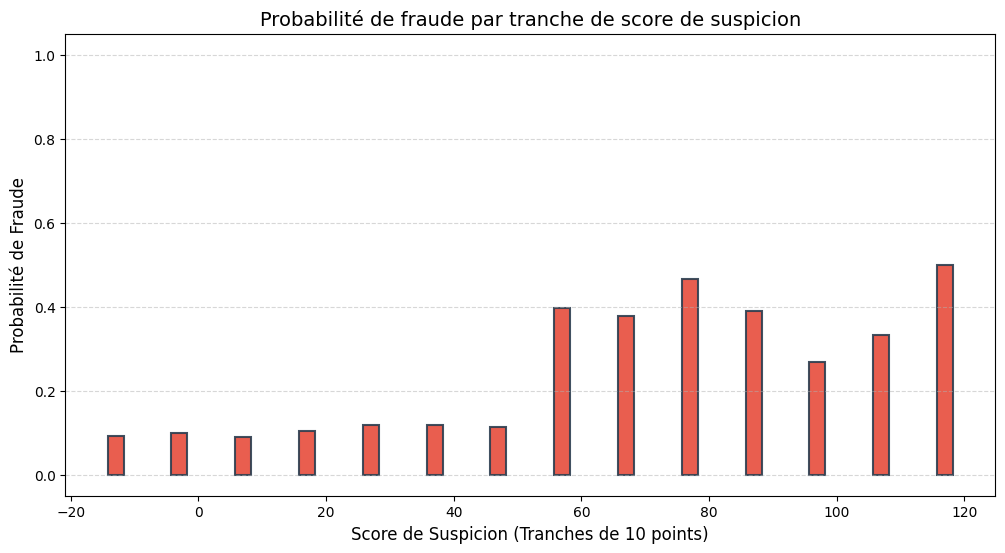

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Conversion en Pandas et création de la cible numérique
score_suspicion_pd = score_suspicion.to_pandas()
score_suspicion_pd['fraud_binary'] = score_suspicion_pd['fraud_reported'].map({'N': 0, 'Y': 1})

# 2. Création des tranches (bins) de 3 points
min_score = int(score_suspicion_pd['suspicion_score'].min())
max_score = int(score_suspicion_pd['suspicion_score'].max())
# On remplace le pas de 5 par 3
tranches = list(range(min_score, max_score + 10, 10)) 

score_suspicion_pd['score_groupe'] = pd.cut(score_suspicion_pd['suspicion_score'], bins=tranches)

# 3. Calcul de la probabilité par groupe
proba_par_groupe = score_suspicion_pd.groupby('score_groupe')['fraud_binary'].agg(['mean', 'count']).reset_index()

# On retire les tranches vides
proba_par_groupe = proba_par_groupe[proba_par_groupe['count'] > 0].copy()

# Point central pour l'axe X
proba_par_groupe['score_center'] = proba_par_groupe['score_groupe'].apply(lambda x: x.mid).astype(float)

# 4. Création du graphique en bâtons
plt.figure(figsize=(12, 6)) # J'ai légèrement élargi la figure pour que les barres respirent

# On remplace plt.plot par plt.bar
plt.bar(
    proba_par_groupe['score_center'], 
    proba_par_groupe['mean'], 
    width=2.5,                # Largeur des barres (légèrement < 3 pour laisser un petit espace)
    color='#E74C3C',          # Couleur de remplissage (le rouge que tu avais)
    edgecolor='#2C3E50',      # Couleur de la bordure des barres
    linewidth=1.5,
    alpha=0.9                 # Légère transparence pour le style
)

plt.title("Probabilité de fraude par tranche de score de suspicion", fontsize=14)
plt.xlabel("Score de Suspicion (Tranches de 10 points)", fontsize=12)
plt.ylabel("Probabilité de Fraude", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, axis='y', linestyle='--', alpha=0.5) # Grille uniquement sur l'axe Y pour les bar charts

plt.savefig("courbe_probabilite_fraude_tranches_batons.png", dpi=300, bbox_inches='tight')
plt.show()